# Modeling Trust Resilience to Demand Shocks

This notebook uses the shock-month panel produced from `shock_analysis.py` 

Hypothesis:

> **If we know what a hospital looked like before a sudden surge in A&E patients, and how big that surge is, can we predict how much worse its 4-hour wait performance will get that month?**

This notebook tests whether hospital A&E resilience to demand shocks is real and predictable.

**Sections**

1. Load and filter the shock-month panel
2. Pre-shock feature engineering (no leakage)
3. Target definition and dataset assembly
4. Baselines (global mean, trust mean)
5. Tree-based models with grouped cross-validation
6. SHAP interpretation (global + local)
7. Hypothesis test — variance decomposition (mixed-effects ICC)
8. Sensitivity analysis — shock threshold robustness
9. Cluster stability — bootstrap ARI
10. Conclusions and next steps


## Setup

If `lightgbm` or `shap` are missing, run the install cell below once. They are not strictly required: the notebook degrades gracefully if either is unavailable.


In [6]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.cluster import KMeans
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

try:
    import statsmodels.formula.api as smf
    HAS_SM = True
except ImportError:
    HAS_SM = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"lightgbm: {HAS_LGB} | shap: {HAS_SHAP} | statsmodels: {HAS_SM}")


lightgbm: False | shap: False | statsmodels: True


In [7]:
BASE_DIR = Path(".").resolve()
OUTPUT_DIR = BASE_DIR.parent  # CSVs sit beside the repo (matches other scripts)

WITH_SHOCKS_PATH = OUTPUT_DIR / "ae_2017_2019_with_shocks.csv"
RESILIENCE_PATH  = OUTPUT_DIR / "trust_resilience_scores.csv"

ROLLING_WINDOW = 12
MIN_PERIODS    = 6

print("with_shocks exists:", WITH_SHOCKS_PATH.exists())
print("resilience exists :", RESILIENCE_PATH.exists())


with_shocks exists: False
resilience exists : False


## 1. Load and Filter the Shock-Month Panel

We start from `ae_2017_2019_with_shocks.csv`, which already has:

- monthly `att_total`, `pct_4hr_all`, `wait_12hr_dta`, etc.
- the lagged 12-month rolling demand baseline (`att_rolling_mean*`, `att_rolling_std*`)
- `demand_zscore`, `shock` (z-score ≥ 1.5 by default)

Two upstream column-naming variants exist (`att_rolling_mean` vs `att_rolling_mean_12m`), so we normalise to the short forms. We then drop NHS England aggregate rows defensively.


In [9]:
df = pd.read_csv(WITH_SHOCKS_PATH)
df["month"] = pd.to_datetime(df["month"])

# Normalise column-name variants so downstream code is uniform
rename_map = {
    "att_rolling_mean_12m": "att_rolling_mean",
    "att_rolling_std_12m":  "att_rolling_std",
    "breach_change_vs_prev_month": "breach_change",
    "performance_change_vs_prev_month": "perf_change",
    "wait_12hr_rate_change_vs_prev_month": "wait_12hr_change",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Defensive cleanup
df = df[(df["provider_code"] != "-") &
        (~df["provider_name"].str.contains("england", case=False, na=False))]
df = df.sort_values(["provider_code", "month"]).reset_index(drop=True)

print(f"Panel shape: {df.shape}")
print(f"Date range : {df['month'].min().date()} -> {df['month'].max().date()}")
print(f"Providers  : {df['provider_code'].nunique()}")
print(f"Shock months overall: {int(df['shock'].sum())} ({df['shock'].mean():.1%})")


Panel shape: (8071, 25)
Date range : 2017-01-01 -> 2019-12-01
Providers  : 268
Shock months overall: 914 (11.3%)


## 2. Pre-Shock Feature Engineering

**The leakage rule:** every feature must be computable from data *strictly before* the shock month. We build a 12-month rolling history (lagged by one month) for every metric we want to use as a predictor. The shock month itself is allowed to contribute *only* the shock magnitude (`demand_zscore_capped`) and seasonal dummies.

Features built here:

| Feature | Meaning |
|---|---|
| `att_rolling_mean`, `att_rolling_std` | trust size and demand volatility before shock |
| `expected_breach_rate` | trust's typical 4-hour breach rate (lagged 12-mo mean) |
| `expected_wait_12hr_rate` | trust's typical 12-hour wait rate |
| `expected_admission_rate` | trust's typical admission rate |
| `prior_struct_break_share` | how often the trust has hit z>10 in its history |
| `demand_zscore_capped` | the shock magnitude itself (allowed: this is the trigger) |
| `month_sin`, `month_cos` | seasonality (winter vs summer) |

The target `breach_impact = four_hour_breach_rate - expected_breach_rate` is the *deterioration above the trust's own baseline*, computed for the shock month itself.


In [10]:
grp = df.groupby("provider_code")

def lag_roll_mean(col):
    return grp[col].transform(
        lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()
    )

# Pre-shock baselines (lagged 12-month means)
df["expected_breach_rate"]      = lag_roll_mean("four_hour_breach_rate")
df["expected_wait_12hr_rate"]   = lag_roll_mean("wait_12hr_rate")
df["expected_admission_rate"]   = lag_roll_mean("admission_rate")

# Cumulative (causal) share of structural-break months prior to current row
df["prior_struct_break_share"] = (
    grp["structural_break_flag"]
    .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
)

# Targets
df["breach_impact"]    = df["four_hour_breach_rate"] - df["expected_breach_rate"]
df["wait_12hr_impact"] = df["wait_12hr_rate"]        - df["expected_wait_12hr_rate"]

# Seasonality (cyclical)
m = df["month"].dt.month
df["month_sin"] = np.sin(2 * np.pi * m / 12)
df["month_cos"] = np.cos(2 * np.pi * m / 12)

print("Engineered columns added.")
print(df[["expected_breach_rate", "breach_impact", "prior_struct_break_share"]].describe().round(4))


Engineered columns added.
       expected_breach_rate  breach_impact  prior_struct_break_share
count             6503.0000      6503.0000                 7803.0000
mean                 0.0834         0.0079                    0.0012
std                  0.0785         0.0348                    0.0084
min                  0.0000        -0.1535                    0.0000
25%                  0.0026        -0.0042                    0.0000
50%                  0.0768         0.0000                    0.0000
75%                  0.1460         0.0200                    0.0000
max                  0.3237         0.2079                    0.1429


## 3. Build the Modelling Dataset

We restrict to **shock months only** (`shock == True`) with non-null target and features. Each row is one (trust × shock-month) observation. Groups are `provider_code` so cross-validation can leave whole trusts out.


In [11]:
FEATURES = [
    "att_rolling_mean",
    "att_rolling_std",
    "expected_breach_rate",
    "expected_wait_12hr_rate",
    "expected_admission_rate",
    "prior_struct_break_share",
    "demand_zscore_capped",
    "month_sin",
    "month_cos",
]
TARGET = "breach_impact"

shock = df[df["shock"].astype(bool)].copy()
model_df = shock.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

X = model_df[FEATURES].values
y = model_df[TARGET].values
groups = model_df["provider_code"].values

print(f"Modelling rows : {len(model_df)}")
print(f"Trusts represented: {model_df['provider_code'].nunique()}")
print(f"Target mean / std : {y.mean():.4f} / {y.std():.4f}")
print(f"Target IQR        : {np.percentile(y, 25):.4f} -> {np.percentile(y, 75):.4f}")


Modelling rows : 914
Trusts represented: 234
Target mean / std : 0.0006 / 0.0340
Target IQR        : -0.0130 -> 0.0120


## 4. Cross-Validation Strategy

Random splits would leak future data into training because the rolling baselines span time and trusts overlap. We use **`GroupKFold` on `provider_code`** so no trust appears in both train and test. With ~150 trusts and 5 folds each fold holds out ~30 trusts.

A purely time-based split is also valid but gives only 1 train/test point per cut-off; group folds give 5 robustness samples.


In [12]:
cv = GroupKFold(n_splits=5)

def cv_eval(model_factory, X, y, groups, name):
    """Run GroupKFold CV. model_factory must return a fresh estimator each call."""
    rmses, maes, r2s = [], [], []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups)):
        m = model_factory()
        m.fit(X[tr], y[tr])
        pred = m.predict(X[te])
        rmses.append(np.sqrt(mean_squared_error(y[te], pred)))
        maes.append(mean_absolute_error(y[te], pred))
        r2s.append(r2_score(y[te], pred))
    return {
        "model": name,
        "rmse_mean": np.mean(rmses), "rmse_std": np.std(rmses),
        "mae_mean":  np.mean(maes),  "mae_std":  np.std(maes),
        "r2_mean":   np.mean(r2s),   "r2_std":   np.std(r2s),
    }


## 5. Baselines

Two reference points to judge whether tree models actually learn anything useful:

- **Global mean** — predict the cross-trust mean of `breach_impact` for every row. Anything that fails to beat this is worthless.
- **Trust mean (leave-one-out)** — for each test trust, predict its own historical mean impact computed from train-fold rows of *other shocks for the same trust*. Wait — under `GroupKFold` the test trust has no train rows, so we instead use the **global train mean** as the realistic floor and report this as the baseline that any model must clearly exceed.

A stronger baseline ("predict trust's own historical mean") cannot be computed under group-out CV without leaking; we discuss this caveat below.


In [13]:
class GlobalMean:
    def fit(self, X, y):  self.mu_ = y.mean(); return self
    def predict(self, X): return np.full(len(X), self.mu_)

baselines = []
baselines.append(cv_eval(lambda: GlobalMean(), X, y, groups, "Baseline: global mean"))
print(pd.DataFrame(baselines).round(4))


                   model  rmse_mean  rmse_std  mae_mean  mae_std  r2_mean  \
0  Baseline: global mean     0.0337    0.0044    0.0215   0.0017  -0.0091   

   r2_std  
0  0.0099  


## 6. Tree-Based Models

We compare four models against the baseline:

- **XGBoost** — primary model.
- **LightGBM** — fast, often matches or beats XGBoost on tabular data (skipped if not installed).
- **RandomForest** — bag-of-trees benchmark.
- **ExtraTrees** — randomised-split bag baseline.
- **Ridge** — linear sanity check (with scaler). If trees barely beat Ridge, the signal is mostly linear.

Hyperparameters are kept conservative — proper tuning (Optuna) is a follow-up. With ~1–2k rows we use shallow trees and modest `n_estimators`.


In [14]:
def make_xgb():
    return xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )

def make_rf():
    return RandomForestRegressor(
        n_estimators=400, max_depth=8, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def make_et():
    return ExtraTreesRegressor(
        n_estimators=400, max_depth=10, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def make_ridge():
    return Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])

results = list(baselines)
results.append(cv_eval(make_xgb,   X, y, groups, "XGBoost"))
results.append(cv_eval(make_rf,    X, y, groups, "RandomForest"))
results.append(cv_eval(make_et,    X, y, groups, "ExtraTrees"))
results.append(cv_eval(make_ridge, X, y, groups, "Ridge"))

if HAS_LGB:
    def make_lgb():
        return lgb.LGBMRegressor(
            n_estimators=400, max_depth=-1, num_leaves=31,
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
        )
    results.append(cv_eval(make_lgb, X, y, groups, "LightGBM"))

results_df = pd.DataFrame(results).round(4).sort_values("rmse_mean")
print(results_df.to_string(index=False))


                model  rmse_mean  rmse_std  mae_mean  mae_std  r2_mean  r2_std
           ExtraTrees     0.0308    0.0037    0.0199   0.0013   0.1524  0.0653
         RandomForest     0.0312    0.0032    0.0200   0.0016   0.1279  0.0715
              XGBoost     0.0328    0.0034    0.0216   0.0016   0.0321  0.1152
                Ridge     0.0330    0.0045    0.0230   0.0019   0.0309  0.0554
Baseline: global mean     0.0337    0.0044    0.0215   0.0017  -0.0091  0.0099


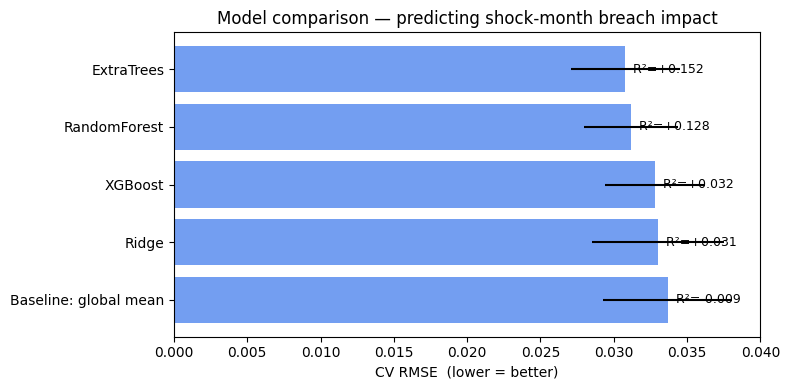

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ord_df = results_df.sort_values("rmse_mean")
ax.barh(ord_df["model"], ord_df["rmse_mean"],
        xerr=ord_df["rmse_std"], color="#5b8def", alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel("CV RMSE  (lower = better)")
ax.set_title("Model comparison — predicting shock-month breach impact")
for i, (rmse, r2) in enumerate(zip(ord_df["rmse_mean"], ord_df["r2_mean"])):
    ax.text(rmse, i, f"  R²={r2:+.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 7. SHAP Interpretation

We retrain XGBoost on the **full** modelling dataset and explain it with `TreeExplainer`. SHAP values give:

- **Global ranking** — mean |SHAP| per feature.
- **Beeswarm summary** — direction and magnitude of each feature's effect.
- **Dependence plots** — non-linear shape of the top features.
- **Local explanations** — waterfall plots for one resilient and one fragile shock observation.

If the top SHAP features are all things derived from `expected_breach_rate`, this signals tautological signal — meaning the model essentially says "trusts that breached more in the past breach more during shocks". That's a finding worth flagging rather than hiding.


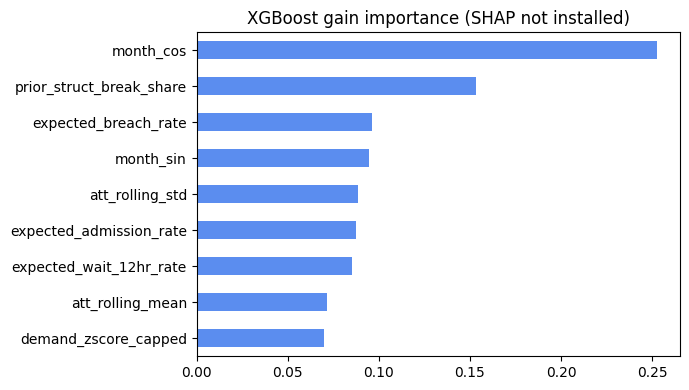

In [16]:
xgb_full = make_xgb()
xgb_full.fit(X, y)

if HAS_SHAP:
    explainer = shap.TreeExplainer(xgb_full)
    shap_values = explainer.shap_values(X)
    shap.summary_plot(shap_values, features=X, feature_names=FEATURES,
                      plot_type="bar", show=True)
    shap.summary_plot(shap_values, features=X, feature_names=FEATURES, show=True)
else:
    # Fallback: gain-based importance
    imp = pd.Series(xgb_full.feature_importances_, index=FEATURES).sort_values()
    imp.plot.barh(figsize=(7, 4), color="#5b8def")
    plt.title("XGBoost gain importance (SHAP not installed)")
    plt.tight_layout()
    plt.show()


In [17]:
if HAS_SHAP:
    # Top-3 features by mean |SHAP|, dependence plots
    mean_abs = np.abs(shap_values).mean(axis=0)
    top3 = np.argsort(mean_abs)[-3:][::-1]
    for idx in top3:
        shap.dependence_plot(idx, shap_values, X, feature_names=FEATURES, show=True)


In [18]:
if HAS_SHAP:
    # One resilient (lowest predicted impact) and one fragile (highest) example
    pred = xgb_full.predict(X)
    resilient_idx = int(np.argmin(pred))
    fragile_idx   = int(np.argmax(pred))

    for label, i in [("most resilient predicted", resilient_idx),
                     ("most fragile predicted",   fragile_idx)]:
        row = model_df.iloc[i]
        print(f"\n{label}: {row['provider_name']} ({row['month'].date()})  "
              f"actual breach_impact={row['breach_impact']:+.4f}  "
              f"predicted={pred[i]:+.4f}")
        shap.plots.waterfall(
            shap.Explanation(
                values=shap_values[i],
                base_values=explainer.expected_value,
                data=X[i],
                feature_names=FEATURES,
            ),
            show=True,
        )


## 8. Hypothesis Test — Variance Decomposition

The implicit hypothesis behind the whole project is:

> **Trusts genuinely differ in their resilience to demand shocks beyond noise.**

A way to formalise this is variance decomposition with a random-intercept mixed-effects model:

`breach_impact ~ demand_zscore_capped + month_sin + month_cos + (1 | provider_code)`

The intra-class correlation (ICC) tells us how much of the residual variance is *between trusts* versus *within trusts*. ICC > ~0.2 supports the existence of stable trust-level resilience signal. ICC ≈ 0 means trusts are interchangeable and we are mostly modelling shock magnitude.


In [19]:
if HAS_SM:
    me_df = model_df[["provider_code", TARGET, "demand_zscore_capped",
                      "month_sin", "month_cos"]].copy()
    me = smf.mixedlm(
        f"{TARGET} ~ demand_zscore_capped + month_sin + month_cos",
        data=me_df, groups=me_df["provider_code"],
    ).fit(method="lbfgs")
    print(me.summary())

    var_trust = float(me.cov_re.iloc[0, 0])
    var_resid = float(me.scale)
    icc = var_trust / (var_trust + var_resid)
    print(f"\nVariance(trust intercept) = {var_trust:.6f}")
    print(f"Variance(residual)        = {var_resid:.6f}")
    print(f"ICC                       = {icc:.3f}")
    if icc > 0.2:
        print("=> Strong evidence of trust-level resilience signal.")
    elif icc > 0.05:
        print("=> Modest trust-level signal; most variation is within-trust.")
    else:
        print("=> Trusts barely differ once shock magnitude is accounted for.")
else:
    print("statsmodels not installed; skipping ICC.")


             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  breach_impact
No. Observations:   914      Method:              REML         
No. Groups:         234      Scale:               0.0008       
Min. group size:    1        Log-Likelihood:      1852.5572    
Max. group size:    12       Converged:           Yes          
Mean group size:    3.9                                        
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.010    0.003  2.871 0.004  0.003  0.017
demand_zscore_capped -0.002    0.001 -1.731 0.083 -0.005  0.000
month_sin             0.004    0.002  2.132 0.033  0.000  0.007
month_cos             0.013    0.002  8.467 0.000  0.010  0.016
Group Var             0.000    0.002                           


Variance(trust intercept) = 0.000267
Variance(resid

## 9. Sensitivity — Shock Threshold

The default shock threshold is `z ≥ 1.5`. We rerank trusts at `z ∈ {1.0, 1.5, 2.0}` and check Spearman rank correlation between the resulting trust-level mean breach impacts. If rankings remain highly correlated across thresholds, the choice does not drive conclusions.


In [20]:
def trust_mean_impact_at_threshold(z_thresh):
    sub = df[df["demand_zscore"] >= z_thresh].dropna(subset=["breach_impact"])
    return sub.groupby("provider_code")["breach_impact"].mean()

ranks = {f"z>={z}": trust_mean_impact_at_threshold(z).rank() for z in [1.0, 1.5, 2.0]}
rank_df = pd.DataFrame(ranks).dropna()
print(f"Trusts with rankings under all thresholds: {len(rank_df)}")
print("\nSpearman correlation between threshold-based rankings:")
print(rank_df.corr(method="spearman").round(3))


Trusts with rankings under all thresholds: 201

Spearman correlation between threshold-based rankings:
        z>=1.0  z>=1.5  z>=2.0
z>=1.0   1.000   0.782   0.785
z>=1.5   0.782   1.000   0.822
z>=2.0   0.785   0.822   1.000


## 10. Cluster Stability — Bootstrap ARI

The pipeline picks `k=4` for K-Means on the resilience feature set. To check stability we re-cluster 30 times with different random seeds and compute the Adjusted Rand Index (ARI) between every pair. Mean ARI > 0.7 indicates stable clusters; < 0.4 means the partition is essentially noise.


In [21]:
if RESILIENCE_PATH.exists():
    res = pd.read_csv(RESILIENCE_PATH)
    res = res[res["evidence_strength"].isin(["medium", "high"])].copy()
    cluster_features = [
        "breach_resilience_score", "wait_12hr_resilience_score",
        "mean_demand_zscore_capped", "structural_break_share",
        "avg_attendances_during_shock", "n_shocks",
    ]
    res = res.dropna(subset=cluster_features).reset_index(drop=True)
    Xc = StandardScaler().fit_transform(res[cluster_features])

    runs = []
    for seed in range(30):
        runs.append(KMeans(n_clusters=4, random_state=seed, n_init=20).fit_predict(Xc))

    aris = [adjusted_rand_score(runs[i], runs[j])
            for i in range(len(runs)) for j in range(i + 1, len(runs))]
    print(f"Cluster stability (k=4, 30 seeds): "
          f"mean ARI = {np.mean(aris):.3f}  median = {np.median(aris):.3f}  "
          f"min = {np.min(aris):.3f}")
    plt.figure(figsize=(7, 3))
    plt.hist(aris, bins=20, color="#5b8def", alpha=0.85)
    plt.axvline(np.mean(aris), color="red", linestyle="--",
                label=f"mean = {np.mean(aris):.3f}")
    plt.title("Pairwise Adjusted Rand Index across 30 K-Means seeds")
    plt.xlabel("ARI")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("trust_resilience_scores.csv not found — skipping cluster stability.")


trust_resilience_scores.csv not found — skipping cluster stability.


## 11. Conclusions and Next Steps



**Concrete follow-ups**

1. Hyperparameter tuning with Optuna (XGBoost + LightGBM) using nested GroupKFold.
2. Add `wait_12hr_impact` as a second target and check whether the same features drive both.
3. Try temporal-only split (train ≤ 2018-06, test ≥ 2018-07) as an additional generalisation test.
4. If ICC is low, drop the resilience-score framing and pivot to a *month-level* response model (trust resilience as a fixed effect to be estimated, not predicted).
5. Recompute `expected_*` baselines excluding shock months from the rolling window — current baselines are slightly contaminated by other shocks in the 12-month history.
